### change ball type to 7+2, add angle , hit location .defensive coverage, fixed the return height and add ball up down feature

In [1]:
import pandas as pd
from src.data_pipeline.feature_engineering import main_data_pipeline

SAMPLE = ""
# SAMPLE = "sample_" 

main_data_pipeline(f"./{SAMPLE}data/{SAMPLE}shot.csv",f"./{SAMPLE}data/{SAMPLE}shot_with_feature.csv")


✅ CSV 數據 './data/shot.csv' 已成功載入！

--- Clean return height ---

--- 球種映射完成 ---
最終分類結果:
ball_type
挑球      10106
網前小球     9934
殺球       8385
平球       6812
推撲球      3582
發短球      3254
切球       3213
長球       2288
發長球       480
未分類       445
Name: count, dtype: int64

--- 1-16 blocks result---
Hitting_Zone
8     14309
4      6674
9      6083
6      6081
5      4976
3      4945
7      3614
2       871
13      473
1       466
12        3
14        3
11        1
Name: count, dtype: int64

--- Partner Angle Bin result ---
Angle_Bin
0    12296
1     5786
2     6593
3    10539
4    12868
5      417
Name: count, dtype: int64

--- add center coverage and formation ---

--- Ball Height Direction result ---
ball_up_down
 1    16643
 2    16628
 0    15003
-1      225
Name: count, dtype: int64

Final output location: './data/shot_with_feature.csv'

--- Final data validation (first few rows) ---
   shot_id  player ball_type Hitting_Zone  Partner_Angle  Angle_Bin  \
0        1       5       發短球         

# Remove the rally which has missing data

## Merge Match, Set, Rally, Shot

In [ ]:
import pandas as pd
import csv
from src.data_pipeline.clean import main_clean_pipeline

SAMPLE = ""
tournament_csv_path = f'./{SAMPLE}data/{SAMPLE}tournament.csv'
match_csv_path = f'./{SAMPLE}data/{SAMPLE}matches.csv'
set_csv_path = f'./{SAMPLE}data/{SAMPLE}set.csv'
rally_csv_path = f'./{SAMPLE}data/{SAMPLE}rally.csv'
shot_csv_path = f'./{SAMPLE}data/{SAMPLE}shot_with_feature.csv'

# ------------------------------------------
# Keep or remove for columns
# ------------------------------------------
tournament_cols_to_keep = ['tournament_id', 'level']
match_cols_to_keep = ['match_id', 'event','tournament_id','duration','set_count']
shot_cols_to_remove = ['time', 'start_frame_num', 'end_frame_num', 'set_num', 'current_win_score', 
                       'current_lose_score', 'Win_rank', 'Lose_rank', 'lose_reason', 'score_team']
rally_cols_to_remove = ['start_frame', 'end_frame', 'comment', 'rally_video_check', 'score_reason','shot_count']


# Tournament
tournament_data = pd.read_csv(tournament_csv_path)
# 移除非必要的欄位
tournament_cols_to_remove = tournament_data.columns.difference(tournament_cols_to_keep).tolist()
tournament_data = tournament_data.drop(columns=tournament_cols_to_remove, errors='ignore')
# 清除 'Super ' 字樣 (加上 .str.strip() 確保前後沒有多餘空白)
tournament_data['level'] = tournament_data['level'].astype(str).str.replace('Super ', '', case=False).str.strip()

# Match
match_data = pd.read_csv(match_csv_path)
match_data['match_id'] = pd.to_numeric(match_data['match_id'], errors='coerce').fillna(0).astype('Int64')
match_data['event'] = pd.to_numeric(match_data['event'], errors='coerce').fillna(0).astype(int)
match_cols_to_remove = match_data.columns.difference(match_cols_to_keep).tolist()
match_data = match_data.drop(columns=match_cols_to_remove, errors='ignore')

# Set
set_data = pd.read_csv(set_csv_path)
set_data['match_id'] = pd.to_numeric(set_data['match_id'], errors='coerce').astype('Int64')

# Rally
rally_data = pd.read_csv(rally_csv_path)
rally_data = rally_data.drop(columns=rally_cols_to_remove, errors='ignore')

# Shot
shot_data = pd.read_csv(shot_csv_path)
shot_data = main_clean_pipeline(shot_data)
shot_data = shot_data.drop(columns=shot_cols_to_remove, errors='ignore')

# Merge
df_match_rally_shot = pd.merge(
        left=shot_data,
        right=rally_data,
        on='rally_id', 
        how='left'     
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=set_data,
        on='set_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=match_data,
        on='match_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )
print("(rows, columns):", df_match_rally_shot.shape)
print("Effective feature：\n", df_match_rally_shot.columns.tolist())
display(df_match_rally_shot.head(10))


[Start Data Clean]...

--- Data Clean Result ---
Origin 48499 rows
Remove 458 rows (coordinate outlier/unclassified/hit_height=0/Error Case)
Final 48041 rows
--- remove result ---
Origin 48041 rows。
323 rally of Exception
Remove 3529 rows。
Final 44512 rows。

[Data Clean Finished]
(rows, columns): (44512, 57)
Effective feature：
 ['shot_id', 'rally_id', 'shot_num', 'player', 'ball_type', 'backhand', 'player_A_x', 'player_A_y', 'player_B_x', 'player_B_y', 'player_C_x', 'player_C_y', 'player_D_x', 'player_D_y', 'hit_x', 'hit_y', 'return_x', 'return_y', 'hit_height', 'return_height', 'flaw', 'A', 'B', 'C', 'D', 'Win', 'Lose', 'is_final_shot', 'Hitting_Zone', 'Partner_Angle', 'Angle_Bin', 'match_Winner_formation', 'match_Loser_formation', 'match_Winner_mid_cover', 'match_Loser_mid_cover', 'shot_count', 'ball_up_down', 'set_id', 'rally_num', 'current_win_score', 'current_lose_score', 'serve_player', 'score_team', 'lose_reason', 'land_x', 'land_y', 'fault_player', 'match_id', 'set_num', 'win_

,shot_id,rally_id,shot_num,player,ball_type,backhand,player_A_x,player_A_y,player_B_x,player_B_y,...,match_id,set_num,win_score,lose_score,set_win,event,tournament_id,set_count,duration,level
0,1,1,1,5,發短球,1,28.639847,94.300792,31.751217,113.677100,...,2,1,21,14,0,1,2,2,37,300
1,2,1,2,7,推撲球,1,34.001378,88.407620,32.780770,114.213560,...,2,1,21,14,0,1,2,2,37,300
2,3,1,3,6,挑球,1,36.690095,87.092290,36.825915,111.609023,...,2,1,21,14,0,1,2,2,37,300
3,4,1,4,8,殺球,0,24.759652,109.455966,48.761037,122.480082,...,2,1,21,14,0,1,2,2,37,300
4,5,1,5,6,平球,1,24.160234,111.525887,46.772711,118.061801,...,2,1,21,14,0,1,2,2,37,300
5,6,1,6,7,推撲球,0,24.894581,115.227577,46.021033,119.147169,...,2,1,21,14,0,1,2,2,37,300
6,7,1,7,6,平球,1,23.988683,114.688232,45.905338,119.146436,...,2,1,21,14,0,1,2,2,37,300
7,8,2,1,8,發短球,1,30.606006,111.047223,41.950872,93.466893,...,2,1,21,14,0,1,2,2,37,300
8,9,2,2,6,網前小球,0,30.711310,108.468965,40.302603,86.235682,...,2,1,21,14,0,1,2,2,37,300
9,10,2,3,8,挑球,0,30.268870,112.088710,30.020094,83.111510,...,2,1,21,14,0,1,2,2,37,300


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
from src.analysis.general_analyze import plot_badminton_shot_analysis, plot_badminton_up_down_analysis, analyze_badminton_rally_stats,  analyze_badminton_shot_distribution


plot_badminton_shot_analysis(df_match_rally_shot)
plot_badminton_up_down_analysis(df_match_rally_shot)

In [ ]:
analyze_badminton_rally_stats(df_match_rally_shot)
analyze_badminton_shot_distribution(df_match_rally_shot)

In [ ]:
from Badminton.DshuttleSet.src.analysis.cce_analysis import global_cce_analysis
global_cce_analysis(df_match_rally_shot, event_type=None
                         , selected_type=['對手落地致勝','未過網','掛網','出界'], shot_to_end=[1,2,3])

In [ ]:
from Badminton.DshuttleSet.src.analysis.tlai_analysis import analyze_defense_aai
analyze_defense_aai(df_match_rally_shot, threat_shot_types = ['殺球', '切球'])

In [ ]:
from src.analysis.defensive_failure import analyze_defensive_failure_rate
analyze_defensive_failure_rate(df_match_rally_shot, event_type=None)
analyze_defensive_failure_rate(df_match_rally_shot, event_type=1)
analyze_defensive_failure_rate(df_match_rally_shot, event_type=2)

Successfully saved plot to: ./img/matches/intensity_analysis.png


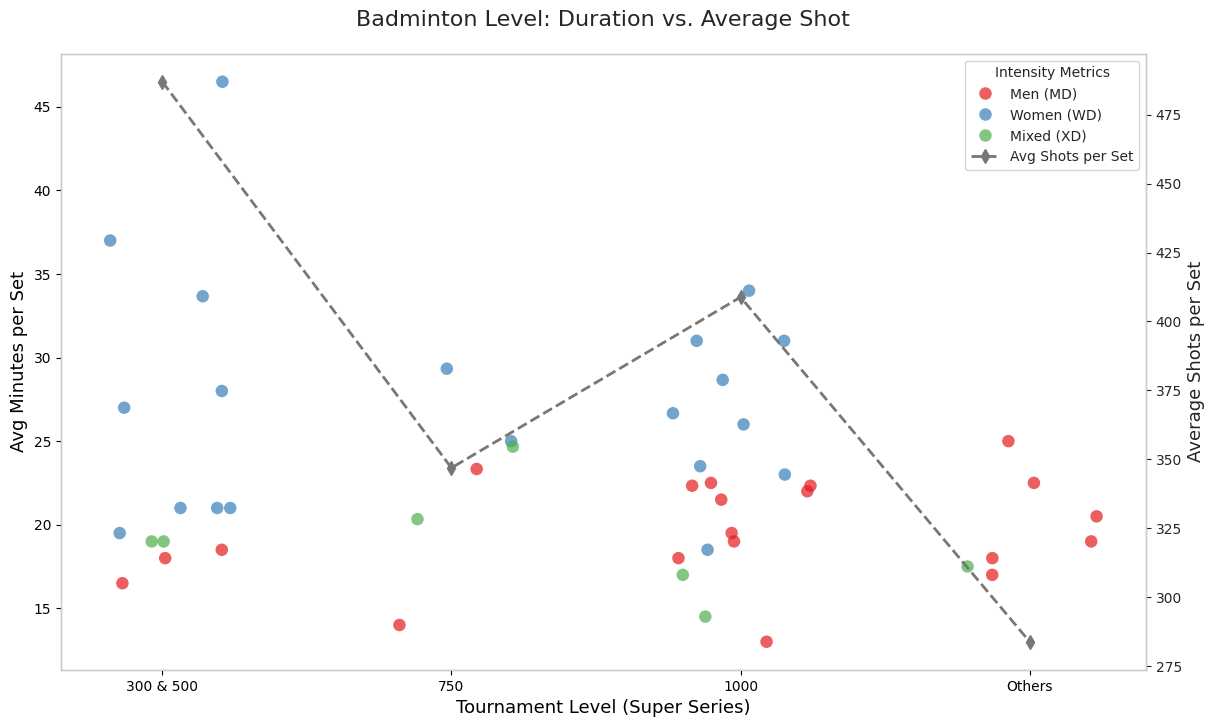

In [2]:
from src.analysis.matches_analyze import plot_badminton_intensity

match_tour_data = pd.merge(
        left=match_data,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )
plot_badminton_intensity(match_tour_data,df_match_rally_shot)